In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
raw = pd.read_excel(
    "/content/cmhc_rent_data.xlsx",
    sheet_name="Table 1.1.2",
    header=None
)

raw.head(12)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"1.1.2 Private Apartment Average Rents ($), by ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Bachelor,NaN,NaN,NaN,1 Bedroom,NaN,NaN,NaN,2 Bedroom,...,NaN,NaN,3 Bedroom +,NaN,NaN,NaN,Total,NaN,NaN,NaN
6,Zone,Oct-23,NaN,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN,Oct-23,...,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN
7,Zone 1 - Toronto (Central),"1,643",a,"1,574",a,"2,005",a,"1,968",a,"2,574",...,"2,627",b,"3,724",b,"3,494",c,"2,114",a,"2,092",a
8,Zone 2 - Toronto (East),"1,128",b,"1,166",c,"1,570",a,"1,627",a,"1,893",...,"1,967",b,**,NaN,**,NaN,"1,618",a,"1,670",a
9,Zone 3 - Toronto (North),"1,554",a,"1,570",a,"1,929",a,"1,889",a,"2,468",...,"2,391",a,"3,609",c,"3,116",c,"2,075",a,"2,033",a


In [31]:
col_names = [
    "Zone",
    "Bachelor_Oct-23", "Bachelor_flag1",
    "Bachelor_Oct-24", "Bachelor_flag2",
    "1_Bedroom_Oct-23", "1_Bedroom_flag1",
    "1_Bedroom_Oct-24", "1_Bedroom_flag2",
    "2_Bedroom_Oct-23", "2_Bedroom_flag1",
    "2_Bedroom_Oct-24", "2_Bedroom_flag2",
    "3_Bedroom_Plus_Oct-23", "3_Bedroom_Plus_flag1",
    "3_Bedroom_Plus_Oct-24", "3_Bedroom_Plus_flag2",
    "Total_Oct-23", "Total_flag1",
    "Total_Oct-24", "Total_flag2"
]

rent_df = raw.iloc[6:].copy()
rent_df.columns = col_names
rent_df = rent_df.reset_index(drop=True)

rent_df.head()

,Zone,Bachelor_Oct-23,Bachelor_flag1,Bachelor_Oct-24,Bachelor_flag2,1_Bedroom_Oct-23,1_Bedroom_flag1,1_Bedroom_Oct-24,1_Bedroom_flag2,2_Bedroom_Oct-23,...,2_Bedroom_Oct-24,2_Bedroom_flag2,3_Bedroom_Plus_Oct-23,3_Bedroom_Plus_flag1,3_Bedroom_Plus_Oct-24,3_Bedroom_Plus_flag2,Total_Oct-23,Total_flag1,Total_Oct-24,Total_flag2
0,Zone,Oct-23,NaN,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN,Oct-23,...,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN,Oct-23,NaN,Oct-24,NaN
1,Zone 1 - Toronto (Central),"1,643",a,"1,574",a,"2,005",a,"1,968",a,"2,574",...,"2,627",b,"3,724",b,"3,494",c,"2,114",a,"2,092",a
2,Zone 2 - Toronto (East),"1,128",b,"1,166",c,"1,570",a,"1,627",a,"1,893",...,"1,967",b,**,NaN,**,NaN,"1,618",a,"1,670",a
3,Zone 3 - Toronto (North),"1,554",a,"1,570",a,"1,929",a,"1,889",a,"2,468",...,"2,391",a,"3,609",c,"3,116",c,"2,075",a,"2,033",a
4,Zone 4 - Toronto (West),"1,205",b,"1,345",a,"1,705",a,"1,667",a,"2,046",...,"1,969",b,"2,851",c,"2,967",c,"1,754",a,"1,747",b


In [32]:
rent_df = rent_df.loc[:, ~rent_df.columns.str.contains("flag")]
rent_df.head()

,Zone,Bachelor_Oct-23,Bachelor_Oct-24,1_Bedroom_Oct-23,1_Bedroom_Oct-24,2_Bedroom_Oct-23,2_Bedroom_Oct-24,3_Bedroom_Plus_Oct-23,3_Bedroom_Plus_Oct-24,Total_Oct-23,Total_Oct-24
0,Zone,Oct-23,Oct-24,Oct-23,Oct-24,Oct-23,Oct-24,Oct-23,Oct-24,Oct-23,Oct-24
1,Zone 1 - Toronto (Central),"1,643","1,574","2,005","1,968","2,574","2,627","3,724","3,494","2,114","2,092"
2,Zone 2 - Toronto (East),"1,128","1,166","1,570","1,627","1,893","1,967",**,**,"1,618","1,670"
3,Zone 3 - Toronto (North),"1,554","1,570","1,929","1,889","2,468","2,391","3,609","3,116","2,075","2,033"
4,Zone 4 - Toronto (West),"1,205","1,345","1,705","1,667","2,046","1,969","2,851","2,967","1,754","1,747"


In [33]:
rent_df = rent_df.replace(['a', 'b', 'c', 'd', 'e', '**'], np.nan)
rent_df = rent_df.replace(',', '', regex=True)

for col in rent_df.columns[1:]:
    rent_df[col] = pd.to_numeric(rent_df[col], errors='coerce')

rent_df.head()

,Zone,Bachelor_Oct-23,Bachelor_Oct-24,1_Bedroom_Oct-23,1_Bedroom_Oct-24,2_Bedroom_Oct-23,2_Bedroom_Oct-24,3_Bedroom_Plus_Oct-23,3_Bedroom_Plus_Oct-24,Total_Oct-23,Total_Oct-24
0,Zone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Zone 1 - Toronto (Central),1643.0,1574.0,2005.0,1968.0,2574.0,2627.0,3724.0,3494.0,2114.0,2092.0
2,Zone 2 - Toronto (East),1128.0,1166.0,1570.0,1627.0,1893.0,1967.0,NaN,NaN,1618.0,1670.0
3,Zone 3 - Toronto (North),1554.0,1570.0,1929.0,1889.0,2468.0,2391.0,3609.0,3116.0,2075.0,2033.0
4,Zone 4 - Toronto (West),1205.0,1345.0,1705.0,1667.0,2046.0,1969.0,2851.0,2967.0,1754.0,1747.0


In [34]:
list(rent_df.columns)

['Zone',
 'Bachelor_Oct-23',
 'Bachelor_Oct-24',
 '1_Bedroom_Oct-23',
 '1_Bedroom_Oct-24',
 '2_Bedroom_Oct-23',
 '2_Bedroom_Oct-24',
 '3_Bedroom_Plus_Oct-23',
 '3_Bedroom_Plus_Oct-24',
 'Total_Oct-23',
 'Total_Oct-24']

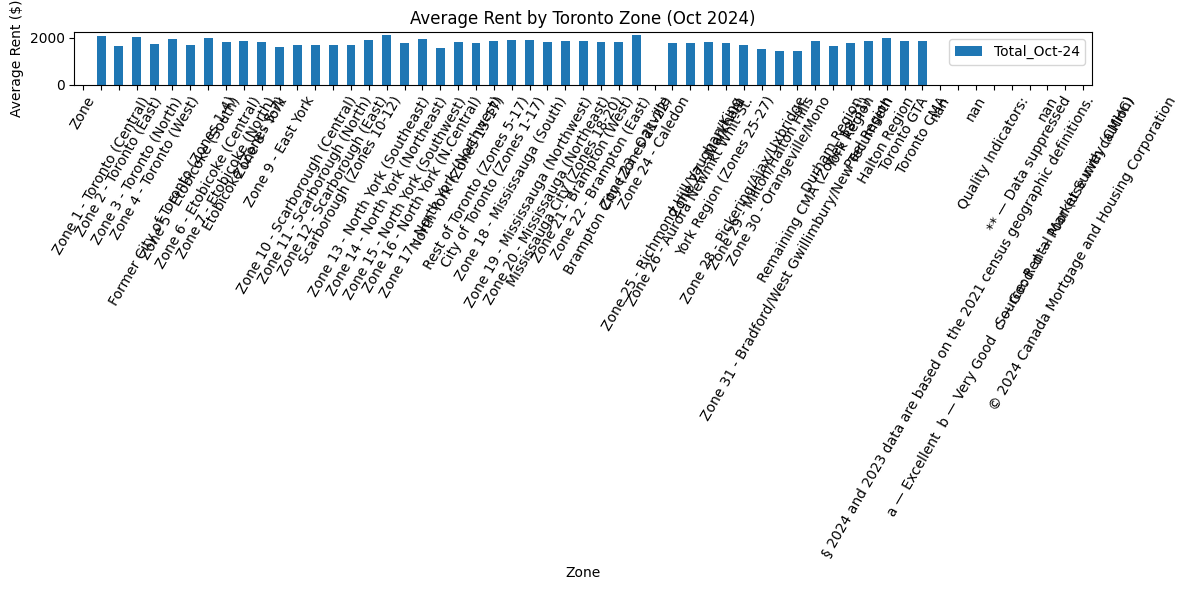

In [35]:
rent_df.plot(
    x="Zone",
    y="Total_Oct-24",
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Rent by Toronto Zone (Oct 2024)")
plt.ylabel("Average Rent ($)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

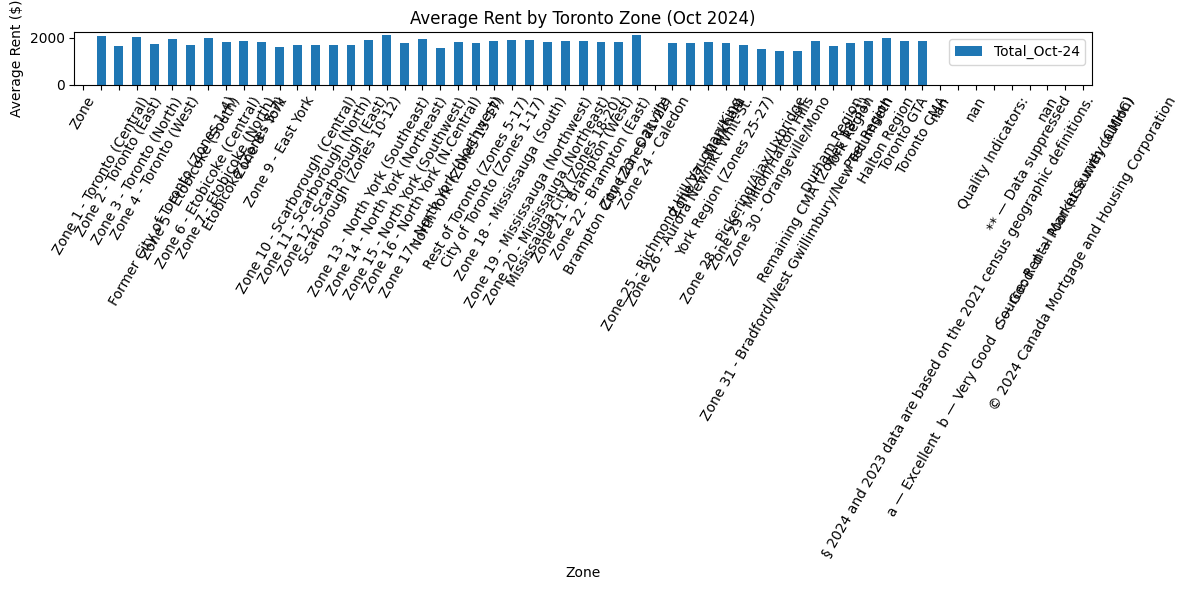

In [36]:
ax = rent_df.plot(
    x="Zone",
    y="Total_Oct-24",
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Rent by Toronto Zone (Oct 2024)")
plt.xlabel("Zone")
plt.ylabel("Average Rent ($)")
plt.xticks(rotation=60)
plt.tight_layout()

plt.savefig("/content/rent_by_zone_2024.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
rent_df.to_csv("/content/cleaned_rent_data.csv", index=False)